In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)
pd.set_option("display.width",None)

In [2]:
def find_true_probabilities_equal(odds):
    probabilities = [1/o for o in odds]
    total_probability = sum(probabilities)
    overround = total_probability - 1
    adjustment_factor = overround / len(odds)
    adjusted_probabilities = [(1/o) - adjustment_factor for o in odds]
    return np.array(adjusted_probabilities)


In [3]:
season_list = ['1617', '1718', '1819', '1920', '2021', '2122', '2223', '2324', '2425']

league_list = ['E0', 'E1', 'E2', 'E3', 'SC0', 'SC1', 'SC2', 'D1', 'D2', 'I1', 'I2', 'SP1', 'SP2', 'F1', 'F2', 'N1', 'B1', 'P1', 'T1', 'G1']  

df_list = []
for league in league_list:
    for season in season_list:
        data_url = f'https://www.football-data.co.uk/mmz4281/{season}/{league}.csv'
        try:
            df = pd.read_csv(data_url)
        except:
            df = pd.read_csv(data_url, encoding='latin')
        df_list.append(df)

main_df = pd.concat(df_list)

main_df['Date'] = pd.to_datetime(main_df['Date'], format='mixed')

main_df = main_df.sort_values(by='Date')

bookmakers = ['B365', 'BW', 'IW', 'PS', 'WH', 'VC']

home_cols = []
draw_cols = []
away_cols = []

for book in bookmakers:
    home_col = book + 'H'
    home_cols.append(home_col)
    draw_col = book + 'D'
    draw_cols.append(draw_col)
    away_col = book + 'A'
    away_cols.append(away_col)

main_df['home_max_odds'] = main_df[home_cols].max(axis=1)
main_df['draw_max_odds'] = main_df[draw_cols].max(axis=1)
main_df['away_max_odds'] = main_df[away_cols].max(axis=1)

main_df.reset_index(inplace=True)

col_list = ['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'PSH', 'PSD', 'PSA', 'home_max_odds', 'draw_max_odds', 'away_max_odds']

main_df = main_df[col_list]


C:\Users\mikko\AppData\Local\Temp\ipykernel_26100\2168323404.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  main_df['home_max_odds'] = main_df[home_cols].max(axis=1)
C:\Users\mikko\AppData\Local\Temp\ipykernel_26100\2168323404.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  main_df['draw_max_odds'] = main_df[draw_cols].max(axis=1)
C:\Users\mikko\AppData\Local\Temp\ipykernel_26100\2168323404.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, whic

In [4]:
main_df = main_df[~main_df['PSH'].isna()]

main_df.reset_index(inplace=True)

In [5]:
main_df[['pinnacle_true_home_prob', 'pinnacle_true_draw_prob', 'pinnacle_true_away_prob']] = main_df.apply(
    lambda row: find_true_probabilities_equal([row['PSH'], row['PSD'], row['PSA']]),
    axis=1,
    result_type='expand'
)

main_df['totes'] = main_df['pinnacle_true_home_prob'] + main_df['pinnacle_true_draw_prob'] + main_df['pinnacle_true_away_prob']

tolerance = 1e-7
mask = np.abs(main_df['totes'] -1 <= tolerance)

assert len(main_df[~mask]) == 0

len(main_df[~mask])

0

In [6]:
def calculate_ev_from_odds(bookmaker_odds, our_probability):
    payout = bookmaker_odds
    ev = (our_probability * payout) -1
    return ev

In [7]:
assert calculate_ev_from_odds(2.0, 0.5) == 0

In [8]:
calculate_ev_from_odds(3.0, 0.5)

0.5

In [9]:
def calculate_kelly_stake(bankroll, ev, odds, kelly_fraction=0.25):
    if odds <= 1 or kelly_fraction <= 0:
        return 0.0
    
    stake_fraction = ev / (odds - 1)

    if stake_fraction <= 0:
        return 0.0
    
    stake_fraction *= kelly_fraction

    return stake_fraction * bankroll

In [10]:
main_df['home_ev'] = main_df.apply(
    lambda row: calculate_ev_from_odds(
        row['home_max_odds'],
        row['pinnacle_true_home_prob']
    ),
    axis=1
)

In [11]:
main_df['draw_ev'] = main_df.apply(
    lambda row: calculate_ev_from_odds(
        row['draw_max_odds'],
        row['pinnacle_true_draw_prob']
    ),
    axis=1
)

In [12]:
main_df['away_ev'] = main_df.apply(
    lambda row: calculate_ev_from_odds(
        row['away_max_odds'],
        row['pinnacle_true_away_prob']
    ),
    axis=1
)

In [14]:
main_df['max_value'] = main_df[['home_ev', 'draw_ev', 'away_ev']].max(axis=1)


In [15]:
main_df

,index,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,PSH,PSD,PSA,home_max_odds,draw_max_odds,away_max_odds,pinnacle_true_home_prob,pinnacle_true_draw_prob,pinnacle_true_away_prob,totes,home_ev,draw_ev,away_ev,max_value
0,0,F2,2016-01-08,Amiens,Reims,1.0,1.0,2.91,2.99,2.88,2.91,3.10,2.88,0.335205,0.326010,0.338785,1.0,-0.024554,0.010633,-0.024300,0.010633
1,1,T1,2016-01-10,Rizespor,Besiktas,0.0,1.0,6.32,4.36,1.57,7.00,4.36,1.57,0.150052,0.221182,0.628767,1.0,0.050362,-0.035648,-0.012836,0.050362
2,2,SP1,2016-01-10,Granada,Leganes,0.0,1.0,2.49,3.42,3.08,2.50,3.42,3.08,0.395380,0.286171,0.318449,1.0,-0.011550,-0.021295,-0.019178,-0.011550
3,3,E3,2016-01-10,Cheltenham,Luton,1.0,1.0,3.30,3.51,2.29,3.30,3.51,2.30,0.294826,0.276696,0.428477,1.0,-0.027073,-0.028796,-0.014502,-0.014502
4,4,E3,2016-01-10,Crawley Town,Blackpool,1.0,0.0,3.92,3.94,1.92,3.92,3.94,2.00,0.245188,0.243893,0.510919,1.0,-0.038864,-0.039062,0.021838,0.021838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62111,62658,SC1,2025-12-04,Queens Park,Dunfermline,0.0,1.0,3.53,3.39,2.04,3.53,3.39,2.05,0.260464,0.272163,0.467374,1.0,-0.080563,-0.077368,-0.041884,-0.041884
62112,62659,I1,2025-12-05,Venezia,Fiorentina,2.0,1.0,3.11,3.28,2.46,3.11,3.28,2.46,0.310568,0.293903,0.395529,1.0,-0.034133,-0.035999,-0.026999,-0.026999
62113,62660,T1,2025-12-05,Kayserispor,Antalyaspor,3.0,1.0,1.96,3.44,3.60,1.96,3.50,3.70,0.483978,0.264471,0.251551,1.0,-0.051404,-0.074351,-0.069260,-0.051404
62114,62661,SP2,2025-12-05,Granada,Eibar,0.0,2.0,1.79,3.44,4.89,1.80,3.44,4.89,0.540707,0.272746,0.186547,1.0,-0.026727,-0.061755,-0.087785,-0.026727


In [ ]:
bankroll_kelly_1 = 100

for i in range(len(main_df)):
    max_ev = main_df.loc[i, 'max_value']
    
    if max_ev <= 0:
        main_df.loc[i, 'betsize_kelly_1'] = 0
        main_df.loc[i, 'bankroll_kelly_1'] = bankroll_kelly_1
        continue

    # Choose one bet: highest +EV outcome
    if max_ev == main_df.loc[i, 'home_ev']:
        odds = main_df.loc[i, 'home_max_odds']
        outcome = 'H'
    elif max_ev == main_df.loc[i, 'draw_ev']:
        odds = main_df.loc[i, 'draw_max_odds']
        outcome = 'D'
    else:
        odds = main_df.loc[i, 'away_max_odds']
        outcome = 'A'

    betsize = calculate_kelly_stake(bankroll_kelly_1, max_ev, odds, 1)
    main_df.loc[i, 'betsize_kelly_1'] = betsize
    bankroll_kelly_1 -= betsize

    # Payout if correct
    if ((outcome == 'H' and main_df.loc[i]['FTHG'] > main_df.loc[i]['FTAG']) or
        (outcome == 'D' and main_df.loc[i]['FTHG'] == main_df.loc[i]['FTAG']) or
        (outcome == 'A' and main_df.loc[i]['FTHG'] < main_df.loc[i]['FTAG'])):
        bankroll_kelly_1 += betsize * odds

    main_df.loc[i, 'bankroll_kelly_1'] = bankroll_kelly_1
    main_df.loc[i, 'bet_on_kelly_1'] = outcome

main_df['bankroll_kelly_1'].plot()



<Axes: >

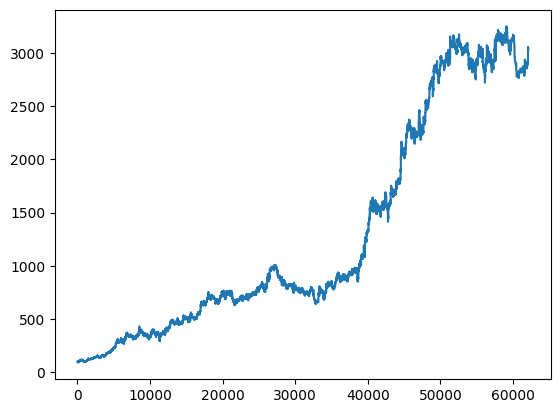

In [43]:
bankroll_kelly_qtr = 100

for i in range(len(main_df)):
    max_ev = main_df.loc[i, 'max_value']
    
    if max_ev <= 0:
        main_df.loc[i, 'betsize_kelly_qtr'] = 0
        main_df.loc[i, 'bankroll_kelly_qtr'] = bankroll_kelly_qtr
        continue

    # Choose one bet: highest +EV outcome
    if max_ev == main_df.loc[i, 'home_ev']:
        odds = main_df.loc[i, 'home_max_odds']
        outcome = 'H'
    elif max_ev == main_df.loc[i, 'draw_ev']:
        odds = main_df.loc[i, 'draw_max_odds']
        outcome = 'D'
    else:
        odds = main_df.loc[i, 'away_max_odds']
        outcome = 'A'

    betsize = calculate_kelly_stake(bankroll_kelly_qtr, max_ev, odds, 0.25)
    main_df.loc[i, 'betsize_kelly_qtr'] = betsize
    bankroll_kelly_qtr -= betsize

    # Payout if correct
    if ((outcome == 'H' and main_df.loc[i]['FTHG'] > main_df.loc[i]['FTAG']) or
        (outcome == 'D' and main_df.loc[i]['FTHG'] == main_df.loc[i]['FTAG']) or
        (outcome == 'A' and main_df.loc[i]['FTHG'] < main_df.loc[i]['FTAG'])):
        bankroll_kelly_qtr += betsize * odds

    main_df.loc[i, 'bankroll_kelly_qtr'] = bankroll_kelly_qtr
    main_df.loc[i, 'bet_on_kelly_qtr'] = outcome

main_df['bankroll_kelly_qtr'].plot()


<Axes: >

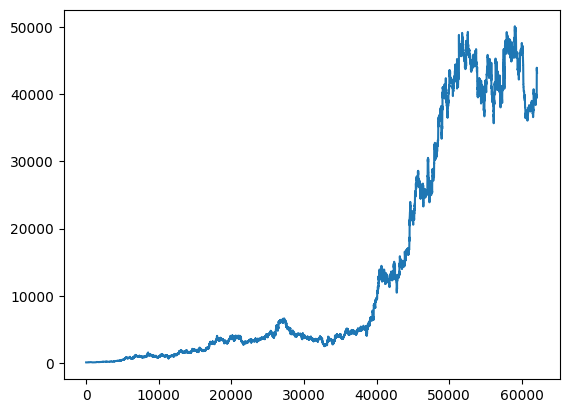

In [44]:
bankroll_kelly_half = 100

for i in range(len(main_df)):
    max_ev = main_df.loc[i, 'max_value']
    
    if max_ev <= 0:
        main_df.loc[i, 'betsize_kelly_half'] = 0
        main_df.loc[i, 'bankroll_kelly_half'] = bankroll_kelly_half
        continue

    # Choose one bet: highest +EV outcome
    if max_ev == main_df.loc[i, 'home_ev']:
        odds = main_df.loc[i, 'home_max_odds']
        outcome = 'H'
    elif max_ev == main_df.loc[i, 'draw_ev']:
        odds = main_df.loc[i, 'draw_max_odds']
        outcome = 'D'
    else:
        odds = main_df.loc[i, 'away_max_odds']
        outcome = 'A'

    betsize = calculate_kelly_stake(bankroll_kelly_half, max_ev, odds, 0.5)
    main_df.loc[i, 'betsize_kelly_half'] = betsize
    bankroll_kelly_half -= betsize

    # Payout if correct
    if ((outcome == 'H' and main_df.loc[i]['FTHG'] > main_df.loc[i]['FTAG']) or
        (outcome == 'D' and main_df.loc[i]['FTHG'] == main_df.loc[i]['FTAG']) or
        (outcome == 'A' and main_df.loc[i]['FTHG'] < main_df.loc[i]['FTAG'])):
        bankroll_kelly_half += betsize * odds

    main_df.loc[i, 'bankroll_kelly_half'] = bankroll_kelly_half
    main_df.loc[i, 'bet_on_kelly_half'] = outcome

main_df['bankroll_kelly_half'].plot()


<Axes: >

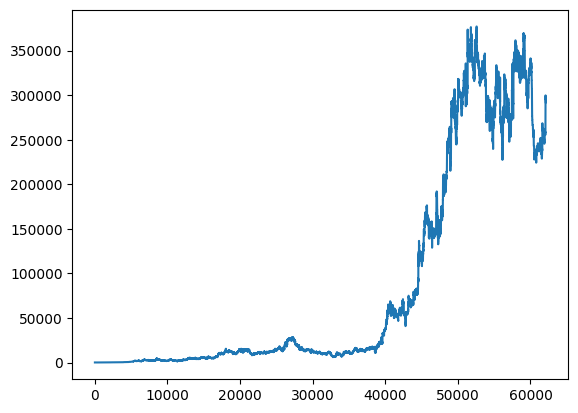

In [42]:
bankroll_kelly_3qtr = 100

for i in range(len(main_df)):
    max_ev = main_df.loc[i, 'max_value']
    
    if max_ev <= 0:
        main_df.loc[i, 'betsize_kelly_3qtr'] = 0
        main_df.loc[i, 'bankroll_kelly_3qtr'] = bankroll_kelly_3qtr
        continue

    # Choose one bet: highest +EV outcome
    if max_ev == main_df.loc[i, 'home_ev']:
        odds = main_df.loc[i, 'home_max_odds']
        outcome = 'H'
    elif max_ev == main_df.loc[i, 'draw_ev']:
        odds = main_df.loc[i, 'draw_max_odds']
        outcome = 'D'
    else:
        odds = main_df.loc[i, 'away_max_odds']
        outcome = 'A'

    betsize = calculate_kelly_stake(bankroll_kelly_3qtr, max_ev, odds, 0.75)
    main_df.loc[i, 'betsize_kelly_3qtr'] = betsize
    bankroll_kelly_3qtr -= betsize

    # Payout if correct
    if ((outcome == 'H' and main_df.loc[i]['FTHG'] > main_df.loc[i]['FTAG']) or
        (outcome == 'D' and main_df.loc[i]['FTHG'] == main_df.loc[i]['FTAG']) or
        (outcome == 'A' and main_df.loc[i]['FTHG'] < main_df.loc[i]['FTAG'])):
        bankroll_kelly_3qtr += betsize * odds

    main_df.loc[i, 'bankroll_kelly_3qtr'] = bankroll_kelly_3qtr
    main_df.loc[i, 'bet_on_kelly_3qtr'] = outcome

main_df['bankroll_kelly_3qtr'].plot()


In [35]:
total_bet_volume = main_df['betsize_kelly_1'].sum()
print(f"Total amount wagered: {total_bet_volume:.2f}")


Total amount wagered: 63251.01


In [38]:
net_winnings = main_df['bankroll_kelly_1'].iloc[-1] - 100  # assuming starting bankroll was 100
print(f"Net winnings: {net_winnings:.2f}")


Net winnings: 2928.06


In [37]:
def is_win(row):
    if row['bet_on_kelly_1'] == 'H' and row['FTHG'] > row['FTAG']:
        return True
    if row['bet_on_kelly_1'] == 'D' and row['FTHG'] == row['FTAG']:
        return True
    if row['bet_on_kelly_1'] == 'A' and row['FTHG'] < row['FTAG']:
        return True
    return False

def get_odds(row):
    if row['bet_on_kelly_1'] == 'H':
        return row['home_max_odds']
    if row['bet_on_kelly_1'] == 'D':
        return row['draw_max_odds']
    if row['bet_on_kelly_1'] == 'A':
        return row['away_max_odds']
    return 0

# Create columns for win flag and odds used
main_df['is_win'] = main_df.apply(is_win, axis=1)
main_df['used_odds'] = main_df.apply(get_odds, axis=1)

# Calculate winnings only for won bets
main_df['winnings'] = main_df['betsize_kelly_1'] * main_df['used_odds'] * main_df['is_win']

# Sum all winnings
total_winnings = main_df['winnings'].sum()
print(f"Total winnings: {total_winnings:.2f}")


Total winnings: 66179.08


In [39]:
main_df

,index,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,PSH,PSD,PSA,home_max_odds,draw_max_odds,away_max_odds,pinnacle_true_home_prob,pinnacle_true_draw_prob,pinnacle_true_away_prob,totes,home_ev,draw_ev,away_ev,max_value,betsize_kelly_1,bankroll_kelly_1,bet_on_kelly_1,is_win,used_odds,winnings
0,0,F2,2016-01-08,Amiens,Reims,1.0,1.0,2.91,2.99,2.88,2.91,3.10,2.88,0.335205,0.326010,0.338785,1.0,-0.024554,0.010633,-0.024300,0.010633,0.126578,100.265813,D,True,3.1,0.392391
1,1,T1,2016-01-10,Rizespor,Besiktas,0.0,1.0,6.32,4.36,1.57,7.00,4.36,1.57,0.150052,0.221182,0.628767,1.0,0.050362,-0.035648,-0.012836,0.050362,0.210400,100.055413,H,False,7.0,0.000000
2,2,SP1,2016-01-10,Granada,Leganes,0.0,1.0,2.49,3.42,3.08,2.50,3.42,3.08,0.395380,0.286171,0.318449,1.0,-0.011550,-0.021295,-0.019178,-0.011550,0.000000,100.055413,NaN,False,0.0,0.000000
3,3,E3,2016-01-10,Cheltenham,Luton,1.0,1.0,3.30,3.51,2.29,3.30,3.51,2.30,0.294826,0.276696,0.428477,1.0,-0.027073,-0.028796,-0.014502,-0.014502,0.000000,100.055413,NaN,False,0.0,0.000000
4,4,E3,2016-01-10,Crawley Town,Blackpool,1.0,0.0,3.92,3.94,1.92,3.92,3.94,2.00,0.245188,0.243893,0.510919,1.0,-0.038864,-0.039062,0.021838,0.021838,0.546261,99.509152,A,False,2.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62111,62658,SC1,2025-12-04,Queens Park,Dunfermline,0.0,1.0,3.53,3.39,2.04,3.53,3.39,2.05,0.260464,0.272163,0.467374,1.0,-0.080563,-0.077368,-0.041884,-0.041884,0.000000,3028.064308,NaN,False,0.0,0.000000
62112,62659,I1,2025-12-05,Venezia,Fiorentina,2.0,1.0,3.11,3.28,2.46,3.11,3.28,2.46,0.310568,0.293903,0.395529,1.0,-0.034133,-0.035999,-0.026999,-0.026999,0.000000,3028.064308,NaN,False,0.0,0.000000
62113,62660,T1,2025-12-05,Kayserispor,Antalyaspor,3.0,1.0,1.96,3.44,3.60,1.96,3.50,3.70,0.483978,0.264471,0.251551,1.0,-0.051404,-0.074351,-0.069260,-0.051404,0.000000,3028.064308,NaN,False,0.0,0.000000
62114,62661,SP2,2025-12-05,Granada,Eibar,0.0,2.0,1.79,3.44,4.89,1.80,3.44,4.89,0.540707,0.272746,0.186547,1.0,-0.026727,-0.061755,-0.087785,-0.026727,0.000000,3028.064308,NaN,False,0.0,0.000000


In [40]:
(main_df['betsize_kelly_1'] > 0).sum()


np.int64(20131)

<Axes: >

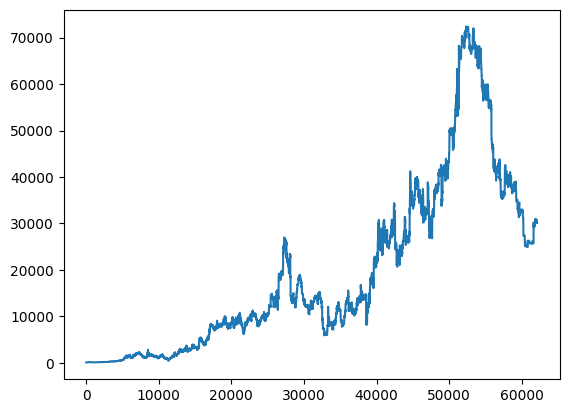

In [12]:
bankroll_kelly_1 = 100

for i in range(len(main_df)):
    betsize_kelly_1 = calculate_kelly_stake(
        bankroll_kelly_1,
        main_df.loc[i]['home_ev'],
        main_df.loc[i]['home_max_odds'],
        1
    )
    main_df.loc[i, 'betsize_kelly_1'] = betsize_kelly_1
    bankroll_kelly_1 -= betsize_kelly_1

    if main_df.loc[i]['FTHG'] > main_df.loc[i]['FTAG']:
        bankroll_kelly_1 += betsize_kelly_1 * main_df.loc[i]['home_max_odds']

    main_df.loc[i, 'bankroll_kelly_1'] = bankroll_kelly_1

main_df['bankroll_kelly_1'].plot()


<Axes: >

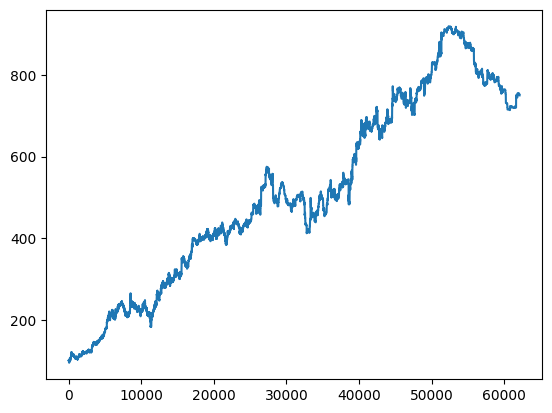

In [13]:
bankroll_kelly_qtr = 100

for i in range(len(main_df)):
    betsize_kelly_qtr = calculate_kelly_stake(
        bankroll_kelly_qtr,
        main_df.loc[i]['home_ev'],
        main_df.loc[i]['home_max_odds'],
        0.25
    )
    main_df.loc[i, 'betsize_kelly_qtr'] = betsize_kelly_qtr
    bankroll_kelly_qtr -= betsize_kelly_qtr

    if main_df.loc[i]['FTHG'] > main_df.loc[i]['FTAG']:
        bankroll_kelly_qtr += betsize_kelly_qtr * main_df.loc[i]['home_max_odds']

    main_df.loc[i, 'bankroll_kelly_qtr'] = bankroll_kelly_qtr

main_df['bankroll_kelly_qtr'].plot()



<Axes: >

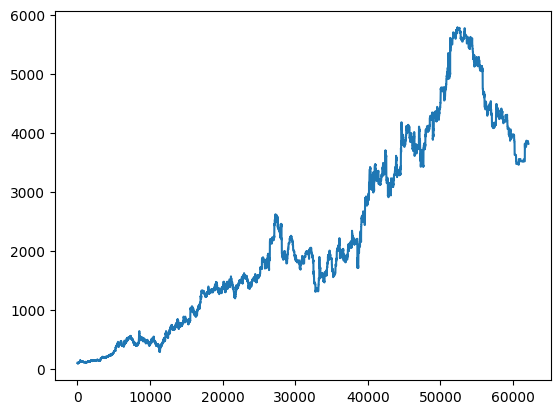

In [14]:
bankroll_kelly_half = 100

for i in range(len(main_df)):
    betsize_kelly_half = calculate_kelly_stake(
        bankroll_kelly_half,
        main_df.loc[i]['home_ev'],
        main_df.loc[i]['home_max_odds'],
        0.5
    )
    main_df.loc[i, 'betsize_kelly_half'] = betsize_kelly_half
    bankroll_kelly_half -= betsize_kelly_half

    if main_df.loc[i]['FTHG'] > main_df.loc[i]['FTAG']:
        bankroll_kelly_half += betsize_kelly_half * main_df.loc[i]['home_max_odds']

    main_df.loc[i, 'bankroll_kelly_half'] = bankroll_kelly_half

main_df['bankroll_kelly_half'].plot()


<Axes: >

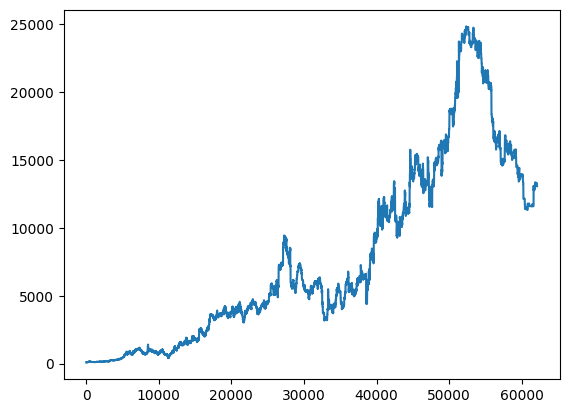

In [15]:
bankroll_kelly_3qtr = 100

for i in range(len(main_df)):
    betsize_kelly_3qtr = calculate_kelly_stake(
        bankroll_kelly_3qtr,
        main_df.loc[i]['home_ev'],
        main_df.loc[i]['home_max_odds'],
        0.75
    )
    main_df.loc[i, 'betsize_kelly_3qtr'] = betsize_kelly_3qtr
    bankroll_kelly_3qtr -= betsize_kelly_3qtr

    if main_df.loc[i]['FTHG'] > main_df.loc[i]['FTAG']:
        bankroll_kelly_3qtr += betsize_kelly_3qtr * main_df.loc[i]['home_max_odds']

    main_df.loc[i, 'bankroll_kelly_3qtr'] = bankroll_kelly_3qtr

main_df['bankroll_kelly_3qtr'].plot()


In [24]:
main_df = main_df[main_df['home_ev'] > 0].copy()


In [29]:
main_df.reset_index(drop=True, inplace=True)


In [45]:
main_df

,index,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,PSH,PSD,PSA,home_max_odds,draw_max_odds,away_max_odds,pinnacle_true_home_prob,pinnacle_true_draw_prob,pinnacle_true_away_prob,totes,home_ev,draw_ev,away_ev,max_value,betsize_kelly_1,bankroll_kelly_1,bet_on_kelly_1,is_win,used_odds,winnings,betsize_kelly_3qtr,bankroll_kelly_3qtr,bet_on_kelly_3qtr,betsize_kelly_qtr,bankroll_kelly_qtr,bet_on_kelly_qtr,betsize_kelly_half,bankroll_kelly_half,bet_on_kelly_half
0,0,F2,2016-01-08,Amiens,Reims,1.0,1.0,2.91,2.99,2.88,2.91,3.10,2.88,0.335205,0.326010,0.338785,1.0,-0.024554,0.010633,-0.024300,0.010633,0.126578,100.265813,D,True,3.1,0.392391,0.379733,100.797440,D,0.126578,100.265813,D,0.253156,100.531627,D
1,1,T1,2016-01-10,Rizespor,Besiktas,0.0,1.0,6.32,4.36,1.57,7.00,4.36,1.57,0.150052,0.221182,0.628767,1.0,0.050362,-0.035648,-0.012836,0.050362,0.210400,100.055413,H,False,7.0,0.000000,0.634547,100.162893,H,0.210400,100.055413,H,0.421916,100.109711,H
2,2,SP1,2016-01-10,Granada,Leganes,0.0,1.0,2.49,3.42,3.08,2.50,3.42,3.08,0.395380,0.286171,0.318449,1.0,-0.011550,-0.021295,-0.019178,-0.011550,0.000000,100.055413,NaN,False,0.0,0.000000,0.000000,100.162893,NaN,0.000000,100.055413,NaN,0.000000,100.109711,NaN
3,3,E3,2016-01-10,Cheltenham,Luton,1.0,1.0,3.30,3.51,2.29,3.30,3.51,2.30,0.294826,0.276696,0.428477,1.0,-0.027073,-0.028796,-0.014502,-0.014502,0.000000,100.055413,NaN,False,0.0,0.000000,0.000000,100.162893,NaN,0.000000,100.055413,NaN,0.000000,100.109711,NaN
4,4,E3,2016-01-10,Crawley Town,Blackpool,1.0,0.0,3.92,3.94,1.92,3.92,3.94,2.00,0.245188,0.243893,0.510919,1.0,-0.038864,-0.039062,0.021838,0.021838,0.546261,99.509152,A,False,2.0,0.000000,1.640544,98.522349,A,0.546261,99.509152,A,1.093115,99.016596,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62111,62658,SC1,2025-12-04,Queens Park,Dunfermline,0.0,1.0,3.53,3.39,2.04,3.53,3.39,2.05,0.260464,0.272163,0.467374,1.0,-0.080563,-0.077368,-0.041884,-0.041884,0.000000,3028.064308,NaN,False,0.0,0.000000,0.000000,292000.608669,NaN,0.000000,3028.064308,NaN,0.000000,43183.374097,NaN
62112,62659,I1,2025-12-05,Venezia,Fiorentina,2.0,1.0,3.11,3.28,2.46,3.11,3.28,2.46,0.310568,0.293903,0.395529,1.0,-0.034133,-0.035999,-0.026999,-0.026999,0.000000,3028.064308,NaN,False,0.0,0.000000,0.000000,292000.608669,NaN,0.000000,3028.064308,NaN,0.000000,43183.374097,NaN
62113,62660,T1,2025-12-05,Kayserispor,Antalyaspor,3.0,1.0,1.96,3.44,3.60,1.96,3.50,3.70,0.483978,0.264471,0.251551,1.0,-0.051404,-0.074351,-0.069260,-0.051404,0.000000,3028.064308,NaN,False,0.0,0.000000,0.000000,292000.608669,NaN,0.000000,3028.064308,NaN,0.000000,43183.374097,NaN
62114,62661,SP2,2025-12-05,Granada,Eibar,0.0,2.0,1.79,3.44,4.89,1.80,3.44,4.89,0.540707,0.272746,0.186547,1.0,-0.026727,-0.061755,-0.087785,-0.026727,0.000000,3028.064308,NaN,False,0.0,0.000000,0.000000,292000.608669,NaN,0.000000,3028.064308,NaN,0.000000,43183.374097,NaN


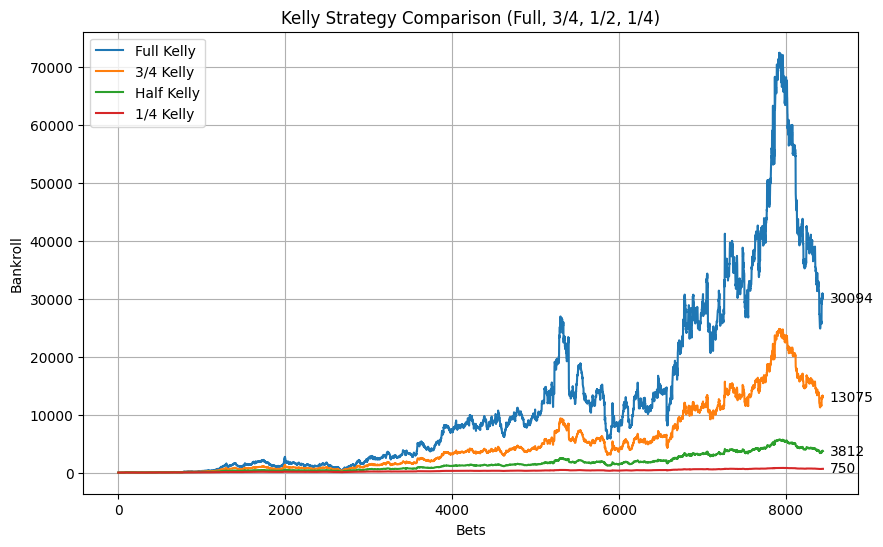

In [31]:
import matplotlib.pyplot as plt

# Plot the bankrolls
ax = main_df[['bankroll_kelly_1', 'bankroll_kelly_3qtr', 'bankroll_kelly_half', 'bankroll_kelly_qtr']].plot(figsize=(10, 6))

# Set labels and title
plt.title('Kelly Strategy Comparison (Full, 3/4, 1/2, 1/4)')
plt.xlabel('Bets')
plt.ylabel('Bankroll')
plt.grid(True)

# Get the last index for annotation
last_index = main_df.index[-1]

# Annotate the last value for each line (rounded to whole number)
for column in ['bankroll_kelly_1', 'bankroll_kelly_3qtr', 'bankroll_kelly_half', 'bankroll_kelly_qtr']:
    value = main_df.loc[last_index, column]
    ax.annotate(f'{value:.0f}', xy=(last_index, value), xytext=(5, 0),
                textcoords='offset points', va='center')

# Customize legend
plt.legend(['Full Kelly', '3/4 Kelly', 'Half Kelly', '1/4 Kelly'])

plt.show()



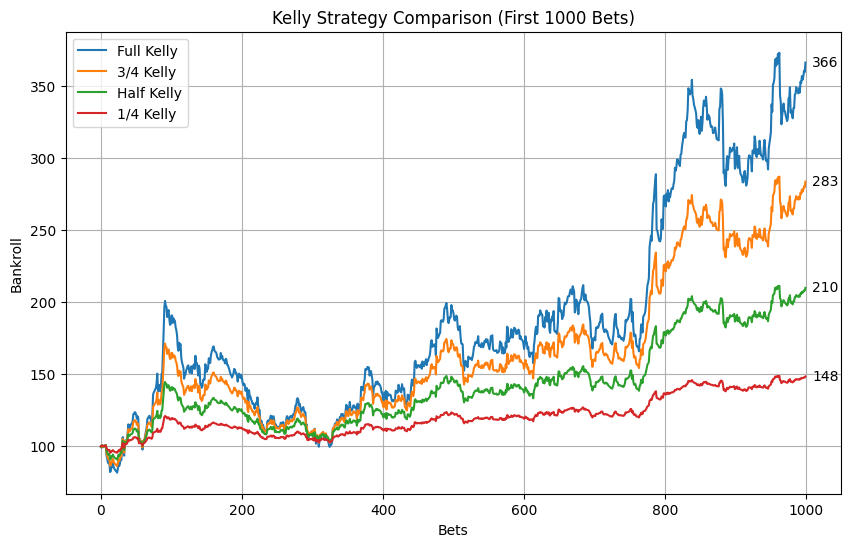

In [32]:
import matplotlib.pyplot as plt

# Slice the first 1000 rows
subset = main_df.iloc[:1000]

# Plot the bankrolls for first 1000 rows
ax = subset[['bankroll_kelly_1', 'bankroll_kelly_3qtr', 'bankroll_kelly_half', 'bankroll_kelly_qtr']].plot(figsize=(10, 6))

# Set labels and title
plt.title('Kelly Strategy Comparison (First 1000 Bets)')
plt.xlabel('Bets')
plt.ylabel('Bankroll')
plt.grid(True)

# Annotate final value (at row 999)
last_index = subset.index[-1]
for column in ['bankroll_kelly_1', 'bankroll_kelly_3qtr', 'bankroll_kelly_half', 'bankroll_kelly_qtr']:
    value = subset.loc[last_index, column]
    ax.annotate(f'{value:.0f}', xy=(last_index, value), xytext=(5, 0),
                textcoords='offset points', va='center')

# Add legend
plt.legend(['Full Kelly', '3/4 Kelly', 'Half Kelly', '1/4 Kelly'])

plt.show()


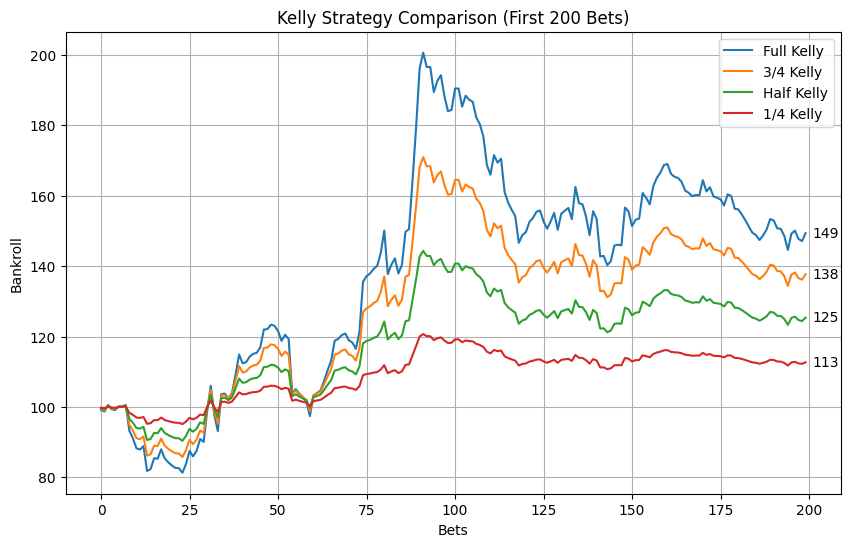

In [34]:
import matplotlib.pyplot as plt

# Create a copy of the first 200 rows
subset = main_df.iloc[:200].copy()

# Plot bankrolls
ax = subset[['bankroll_kelly_1', 'bankroll_kelly_3qtr', 'bankroll_kelly_half', 'bankroll_kelly_qtr']].plot(figsize=(10, 6))

# Labels and title
plt.title('Kelly Strategy Comparison (First 200 Bets)')
plt.xlabel('Bets')
plt.ylabel('Bankroll')
plt.grid(True)

# Annotate final value at row 199
last_index = subset.index[-1]
for column in ['bankroll_kelly_1', 'bankroll_kelly_3qtr', 'bankroll_kelly_half', 'bankroll_kelly_qtr']:
    value = subset.loc[last_index, column]
    ax.annotate(f'{value:.0f}', xy=(last_index, value), xytext=(5, 0),
                textcoords='offset points', va='center')

# Add legend
plt.legend(['Full Kelly', '3/4 Kelly', 'Half Kelly', '1/4 Kelly'])

plt.show()
